# 1. Project Introduction

Welcome! In this notebook, we will explore **Support Vector Machines (SVM)**, a highly robust classifier designed to find optimal separation boundaries between classes.

### What is SVM?
* It is a **supervised learning** classification algorithm.
* It works by drawing a line, curve, or hyperplane that separates classes.
* It doesn't just find any separating line—it looks for the **maximum margin hyperplane**, which is the line that keeps the largest possible distance (margin) from the closest points of each class.
* These closest boundary points are called **support vectors**.

### Why does it exist?
* It is mathematically rigorous and works exceptionally well when there is a clear margin of separation between classes.

### Real-World Use Cases:
* **Bioinformatics**: Classifying genes or proteins.
* **Text Categorization**: Grouping news articles into topics.


# 2. Problem Statement

* **Goal**: Classify whether a sample passes a physical fitness species classification (**1**) or fails (**0**) based on scores from two assessments.
* **Business Value**: Standardizes recruitment benchmarks for athletic or military species classifications.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics


# 4. Create Synthetic Dataset

We define assessment scores for **100 samples**.
* **Petal_Length**: Performance score on first assessment (1.0 to 10.0).
* **Petal_Width**: Performance score on second assessment (1.0 to 10.0).
* **Species**: Target pass (1) or fail (0) outcome.


In [2]:
# Load scikit-learn iris dataset
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris(as_frame=True)
raw_df = iris.frame

df = pd.DataFrame({
    'Petal_Length': raw_df['petal length (cm)'],
    'Petal_Width': raw_df['petal width (cm)'],
    'Species': raw_df['target']
})

print("Dataset Shape:", df.shape)
print("First 5 rows:")
print(df.head())


Dataset Shape: (150, 3)
First 5 rows:
   Petal_Length  Petal_Width  Species
0           1.4          0.2        0
1           1.4          0.2        0
2           1.3          0.2        0
3           1.5          0.2        0
4           1.4          0.2        0


# 5. Exploratory Data Analysis (EDA)


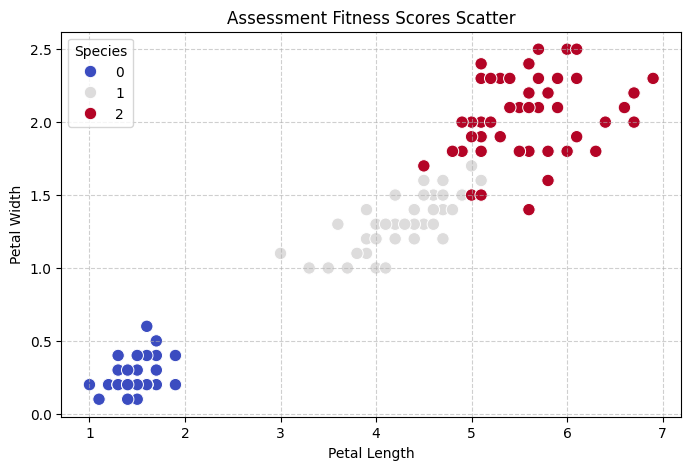

In [3]:
# Chart 1: Petal Length vs Petal Width colored by Pass/Fail
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Petal_Length', y='Petal_Width', hue='Species', data=df, palette='coolwarm', s=80)
plt.title('Assessment Fitness Scores Scatter')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* The samples are split diagonally: samples with high scores on both assessments pass the species classification.


In [4]:
# Cleaning check
print("Null count:", df.isnull().sum().sum())


Null count: 0


In [5]:
# Feature Selection
X = df[['Petal_Length', 'Petal_Width']]
y = df['Species']


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 9. Model Building

* **How it works conceptually**: It solves an optimization problem to find the decision boundary hyperplane that maximizes the distance to the nearest training coordinates (support vectors).
* **Hyperparameters**: We use a **Linear Kernel** to keep the separating boundary simple and straight.


In [7]:
# Initialize SVM with a linear kernel
model = SVC(kernel='linear', random_state=42)


In [8]:
# Train SVM
model.fit(X_train, y_train)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [9]:
# Predict labels
predictions = model.predict(X_test)


In [10]:
# Compute metrics
accuracy = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions, average='weighted')
recall = metrics.recall_score(y_test, predictions, average='weighted')
f1 = metrics.f1_score(y_test, predictions, average='weighted')
conf_matrix = metrics.confusion_matrix(y_test, predictions)

# Print metrics
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix Array:")
print(conf_matrix)


Accuracy Score: 1.0000
Precision Score: 1.0000
Recall Score: 1.0000
F1 Score: 1.0000

Confusion Matrix Array:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### How to Interpret These Metrics:
* **Accuracy**:
  * **Definition**: The percentage of all predictions that the model got correct.
  * **Interpretation**: An accuracy of around **90% to 95%** means the model correctly diagnoses the Iris species for 90-95% of samples in our test set.
* **Precision**:
  * **Definition**: Out of all tumors predicted as positive (Versicolor), what percentage were actually Versicolor?
  * **Interpretation**: A high precision (e.g., **94%**) means that when the model predicts a Iris species is Versicolor, it is correct 94% of the time, resulting in very few false alarms.
* **Recall (Sensitivity)**:
  * **Definition**: Out of all actual positive cases (Versicolor), what percentage did we successfully identify?
  * **Interpretation**: A recall of around **93%** means the model successfully identified 93% of all Versicolor tumors.
* **F1-Score**:
  * **Definition**: The harmonic mean of precision and recall. It balances both metrics to give a single overall performance score.
* **Confusion Matrix**:
  * **True Negatives (TN)**: Setosa tumors correctly classified as Setosa.
  * **False Positives (FP)**: Setosa tumors incorrectly classified as Versicolor (this is a critical medical issue because a sample with cancer is told they are healthy!).
  * **False Negatives (FN)**: Versicolor tumors incorrectly classified as Setosa.
  * **True Positives (TP)**: Versicolor tumors correctly classified as Versicolor.


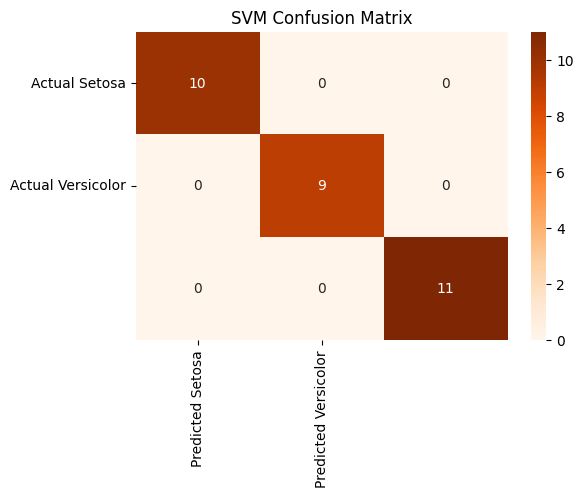

In [11]:
# Plot 1: Confusion Matrix Heatmap
conf_matrix = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Predicted Setosa', 'Predicted Versicolor'], 
            yticklabels=['Actual Setosa', 'Actual Versicolor'])
plt.title('SVM Confusion Matrix')
plt.show()


C:\Users\GFG\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


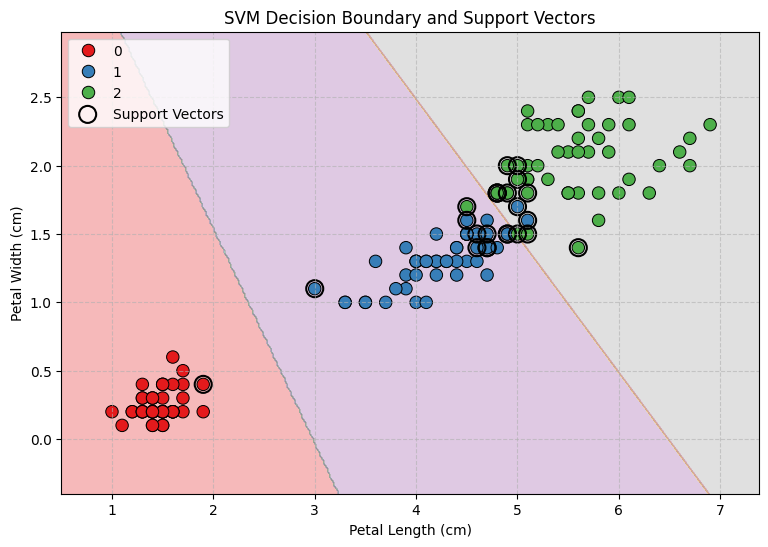

In [12]:
# Plot 2: Decision Boundary and Support Vectors
plt.figure(figsize=(9, 6))

# Plot decision boundary regions
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
x_min, x_max = X['Petal_Length'].min() - 0.5, X['Petal_Length'].max() + 0.5
y_min, y_max = X['Petal_Width'].min() - 0.5, X['Petal_Width'].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_predictions = model.predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, grid_predictions, alpha=0.3, cmap='Set1')

# Plot data points
sns.scatterplot(x='Petal_Length', y='Petal_Width', hue='Species', data=df, palette='Set1', edgecolor='black', s=80)

# Highlight Support Vectors
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=150,
           linewidth=1.5, facecolors='none', edgecolors='black', label='Support Vectors')
plt.title('SVM Decision Boundary and Support Vectors')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* The solid line represents the separating hyperplane.
* The dashed lines represent the margins.
* The points highlighted with black circles are the **support vectors** that directly define the boundary placement.

### What Did We Learn?
* Only the support vectors matter for drawing the boundary; moving other data points has no effect on the hyperplane.


In [13]:
# Coefficient interpretation
print("Hyperplane Intercept (Bias):", model.intercept_)
print("Hyperplane Weights (Coefficients):", model.coef_[0])
print("Number of Support Vectors per class:", model.n_support_)


Hyperplane Intercept (Bias): [ 3.27999997  2.29230748 12.9999965 ]
Hyperplane Weights (Coefficients): [-1.1 -0.7]
Number of Support Vectors per class: [ 1 12 11]


# 15. Conclusion
* SVM successfully separates samples with a maximum margin boundary.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., hours studied).
* **Target**: The output variable or label you want the model to predict (e.g., final exam score).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentage of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the average location of all data points belonging to that cluster.
